# Actividad | Análisis descriptivo

Se selecciono el reporte correspondiente al año del 2015 siendo identificado por el archivo WHR_2015.vsc

# 1. Identificar las variables disponibles

Lista de todas las variables

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

file_name = 'WHR_2015.csv'

# Load data into a pandas DataFrame
df = pd.read_csv(file_name)

# Mostramos todas las variables del DataFrame
print(df.columns)

# mostramos las unidades de medida de cada variable
print(df.dtypes)

Index(['country', 'region', 'happiness_score', 'gdp_per_capita',
       'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption'],
      dtype='str')
country                             str
region                              str
happiness_score                 float64
gdp_per_capita                  float64
social_support                  float64
healthy_life_expectancy         float64
freedom_to_make_life_choices    float64
generosity                      float64
perceptions_of_corruption       float64
dtype: object


| Variable | Definición | Unidades de medida | Tipo de variable | Función (Rol) |
| :--- | :--- | :--- | :--- | :--- |
| `country` | Nombre del país al que corresponden los estadísticos. | N/A | Categórica nominal | **Identificador** |
| `region` | Región geográfica del mundo a la que pertenece el país. | N/A | Categórica nominal | **Grupo** |
| `happiness_score` | Promedio nacional de las respuestas a preguntas relacionadas con la evaluación de vida. | Puntos (0–10) | Numérica continua | **Respuesta** |
| `gdp_per_capita` | Producto interno bruto de un país dividido entre su población; representa el nivel económico promedio por habitante, ajustado por el poder adquisitivo. | Dólares internacionales (PPP) | Numérica continua | **Explicativa** |
| `social_support` | Promedio nacional de las respuestas a la pregunta de si una persona tiene familiares o amigos en quienes puede confiar y contar para recibir ayuda cuando lo necesita. | Puntos de contribucion | Numérica continua | **Explicativa** |
| `healthy_life_expectancy` | Número estimado de años que una persona puede esperar vivir con buena salud desde su nacimiento, considerando las condiciones de salud de la población de su país (normalizado). | Puntos de contribucion | Numérica continua | **Explicativa** |
| `freedom_to_make_life_choices` | Promedio de las respuestas a la pregunta sobre si las personas están satisfechas con su libertad para elegir qué hacer con su vida. | Proporción (0–1) | Numérica continua | **Explicativa** |
| `generosity` | Medida de la generosidad de un país basada en las respuestas sobre si las personas han donado a alguna organización benéfica durante el último mes, ajustada por el PIB per cápita. | Proporción (0–1) | Numérica continua | **Explicativa** |
| `perceptions_of_corruption` | Promedio nacional de la percepción de los ciudadanos sobre el nivel de corrupción en el gobierno y en las empresas. | Proporción (0–1) | Numérica continua | **Explicativa** |

En este caso no hay una muestra en especifico sino una poblacion la cual incluye todos los paises que fueron incluidos en el reporte. En caso de que se quisiera hacer una muetsra se podrian eleguir paises de forma aleatoria de esta poblacion para formar la muestra.

# 2. Revisar la calidad de los datos

Numero de observaciones

In [102]:
# Mostrar el numero de observaciones y variables del DataFrame
print( f"Numero de observaciones: {df.shape[0]}, Numero de variables: {df.shape[1]}")

Numero de observaciones: 158, Numero de variables: 9


Identificar datos faltantes por variable.

In [103]:
# Checamos si hay valores faltantes en el DataFrame
print(df.isnull().sum())

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64


Identificar los tipos de datos

In [104]:
#impriminos el tipo de datos de cada columna
print(df.dtypes)

country                             str
region                              str
happiness_score                 float64
gdp_per_capita                  float64
social_support                  float64
healthy_life_expectancy         float64
freedom_to_make_life_choices    float64
generosity                      float64
perceptions_of_corruption       float64
dtype: object


En este caso no se detecto ningun valor faltante pero se observo que estos fueron remplazados por 0 previamente. Entonces se decidio eliminar estos registros, ya que dejarlos y remplazarlos podria sesgar los resultados de los estadisticos siguientes.

In [105]:
print(f"Total de registros antes de eliminar los con valores faltantes: {len(df)}")

# Transformando 0 s a NaN en todas las columnas del DataFrame
df.replace(0, np.nan, inplace=True)

print(df.isnull().sum())




Total de registros antes de eliminar los con valores faltantes: 158
country                         0
region                          0
happiness_score                 0
gdp_per_capita                  1
social_support                  1
healthy_life_expectancy         1
freedom_to_make_life_choices    1
generosity                      1
perceptions_of_corruption       1
dtype: int64


Checamos las estadisticas de estas columnas con valores 0 (ahorra nans) para ver si hay valores minimos similares o no. 

In [106]:
# Checamos las estadisticas descriptiva de las columnas con valores nans

print(df.describe())



       happiness_score  gdp_per_capita  social_support  \
count       158.000000      157.000000      157.000000   
mean          5.375734        0.851527        0.997358   
std           1.145010        0.398660        0.261389   
min           2.839000        0.015300        0.139950   
25%           4.526000        0.546490        0.860400   
50%           5.232500        0.918510        1.032760   
75%           6.243750        1.159910        1.216240   
max           7.587000        1.690420        1.402230   

       healthy_life_expectancy  freedom_to_make_life_choices  generosity  \
count               157.000000                    157.000000  157.000000   
mean                  0.634274                      0.431345    0.238807   
std                   0.242644                      0.147203    0.125653   
min                   0.047760                      0.076990    0.001990   
25%                   0.440550                      0.328780    0.152750   
50%                  

En este caso se observo que existian multiples valores muy cercanos a 0 por lo cual se decidio dejarlos considerando que las variables en las cuales se observo el 0 eran resultados de variables de proporciones o variables que se normalizaron.

In [112]:
# remplazar nans por 0
df.fillna(0, inplace=True)

# Checamos el numero de valores nans en el DataFrame
print(df.isnull().sum())

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64


Revisar registros duplicados

In [108]:
# Checamos si hay valores duplicados en el DataFrame
print(df.duplicated().sum())

0


checamos por duplicados en los nombres
No hay duplicados

In [109]:

# Ver regiones únicas ordenadas alfabéticamente
print("--- Lista de Regiones Únicas ---")
print(sorted(df['region'].dropna().unique()))

# Ver cantidad de países únicos vs total de filas
print(f"\nCantidad de filas: {len(df)}")
print(f"Países únicos: {df['country'].nunique()}")


# Eliminar espacios al inicio y al final en cadenas de texto
df['country'] = df['country'].astype(str).str.strip()
df['region'] = df['region'].astype(str).str.strip()

# Reemplazar múltiples espacios internos por un solo espacio
df['country'] = df['country'].str.replace(r'\s+', ' ', regex=True)
df['region'] = df['region'].str.replace(r'\s+', ' ', regex=True)


# Comprobar si hay inconsistencias de mayúsculas/minúsculas en 'region'
regiones_originales = df['region'].nunique()
regiones_lower = df['region'].str.lower().nunique()

if regiones_originales != regiones_lower:
    print("Se detectaron regiones con diferencias de mayúsculas/minúsculas.")
else:
    print("No hay duplicados por diferencias de mayúsculas/minúsculas en 'region'.")

# Comprobar lo mismo en 'country'
paises_originales = df['country'].nunique()
paises_lower = df['country'].str.lower().nunique()

if paises_originales != paises_lower:
    print("Se detectaron países con diferencias de mayúsculas/minúsculas.")
else:
    print("No hay duplicados por diferencias de mayúsculas/minúsculas en 'country'.")

--- Lista de Regiones Únicas ---
['Africa', 'Central and Eastern Europe', 'Commonwealth of Independent States', 'East Asia', 'Latin America and Caribbean', 'Middle East and North Africa', 'North America and ANZ', 'South Asia', 'Southeast Asia', 'Sub-Saharan Africa', 'Western Europe']

Cantidad de filas: 158
Países únicos: 158
No hay duplicados por diferencias de mayúsculas/minúsculas en 'region'.
No hay duplicados por diferencias de mayúsculas/minúsculas en 'country'.


Buscar valores imposibles o fuera del rango esperado.
Verificar que las unidades sean consistentes.

Se observo que todos estaban dentro del rango esperado, hapiness score del 1-10, gdp_per_capita, social support y health life expectacy dentro de lo esperado y el resto en una escala de 0 a 1

In [110]:
print (df.describe())

       happiness_score  gdp_per_capita  social_support  \
count       158.000000      158.000000      158.000000   
mean          5.375734        0.846137        0.991046   
std           1.145010        0.403121        0.272369   
min           2.839000        0.000000        0.000000   
25%           4.526000        0.545808        0.856823   
50%           5.232500        0.910245        1.029510   
75%           6.243750        1.158448        1.214405   
max           7.587000        1.690420        1.402230   

       healthy_life_expectancy  freedom_to_make_life_choices  generosity  \
count               158.000000                    158.000000  158.000000   
mean                  0.630259                      0.428615    0.237296   
std                   0.247078                      0.150693    0.126685   
min                   0.000000                      0.000000    0.000000   
25%                   0.439185                      0.328330    0.150553   
50%                  

Identificar valores atipicos

Valores atípicos en 'happiness_score': []
Valores atípicos en 'gdp_per_capita': []
Valores atípicos en 'social_support': [0.0, 0.30285, 0.13995]
Valores atípicos en 'healthy_life_expectancy': []
Valores atípicos en 'freedom_to_make_life_choices': []
Valores atípicos en 'generosity': [0.5763, 0.79588]
Valores atípicos en 'perceptions_of_corruption': [0.41978, 0.48357, 0.36503, 0.41372, 0.43844, 0.42922, 0.37798, 0.38583, 0.4921, 0.52208, 0.37124, 0.39928, 0.38331, 0.55191]


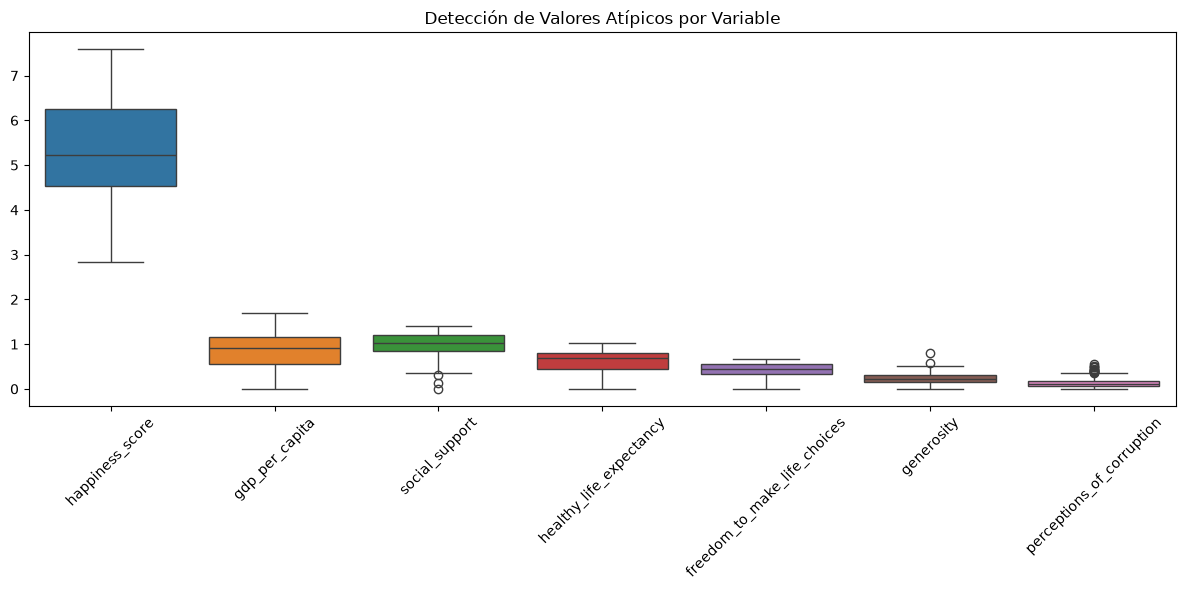

In [111]:
# Usamos IQR para identificar valores atípicos (Outliers) en las columnas numéricas
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

# Mostramos los valores atípicos por columna
outliers = {}
for col in df.select_dtypes(include=np.number).columns:
    outliers[col] = df[(df[col] < (Q1[col] - 1.5 * IQR[col])) | (df[col] > (Q3[col] + 1.5 * IQR[col]))][col]
    print(f"Valores atípicos en '{col}': {outliers[col].tolist()}")

#Identificar valores atípicos (Outliers) mediante Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title('Detección de Valores Atípicos por Variable')
plt.tight_layout()
plt.show()